<a href="https://colab.research.google.com/github/N17-R4M/bigdata-lab-FFLM/blob/main/Analise_Explorat%C3%B3ria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Big Data: Análise do Exame Nacional (2024)

Este notebook apresenta a etapa de Análise Exploratória de Dados (EDA) e Limpeza das bases do exame.
Para garantir a colaboração e evitar limitações de memória, os dados estão hospedados no Google Drive, permitindo que toda a nova equipe acesse a mesma fonte de dados de forma sincronizada.

## 1.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # Já provisionado para a Etapa 3 (Machine Learning)
from google.colab import drive

# Configuração visual padrão para os gráficos do projeto
sns.set_theme(style="whitegrid", palette="muted")

# 2. Conexão com o repositório de dados (Google Drive)
drive.mount('/content/drive')
caminho_drive = '/content/drive/MyDrive/Projeto_ENEM/'

# 3. Leitura dos microdados
# Justificativa técnica:
# - sep=';' e encoding='latin1' são o padrão dos sistemas do INEP.
# - low_memory=False garante a leitura integral e evita erros de inferência de tipagem em bases massivas.
df_participantes = pd.read_csv(caminho_drive + 'PARTICIPANTES_2024.csv', sep=';', encoding='latin1', low_memory=False)
df_resultados = pd.read_csv(caminho_drive + 'RESULTADOS_2024.csv', sep=';', encoding='latin1', low_memory=False)

# 4. Validação da Ingestão (Sanity Check)
print(f"Base de Participantes carregada: {df_participantes.shape[0]} linhas e {df_participantes.shape[1]} colunas.")
print(f"Base de Resultados carregada: {df_resultados.shape[0]} linhas e {df_resultados.shape[1]} colunas.\n")

# Listagem do Schema (Colunas disponíveis)
print("Colunas da base Participantes:", df_participantes.columns.tolist())
print("\nColunas da base Resultados:", df_resultados.columns.tolist())

# 5. Inspeção Visual dos Dados
# Força o Pandas a renderizar TODAS as colunas, impedindo a ocultação com "..."
pd.set_option('display.max_columns', None)

print("\nVISUALIZAÇÃO: BASE DE PARTICIPANTES (Amostra das Primeiras e Últimas 5 linhas)")
# O concat de head() e tail() permite auditar o início e o fim da ingestão de uma só vez
display(pd.concat([df_participantes.head(), df_participantes.tail()]))

print("\n" + "="*80 + "\n")

print("VISUALIZAÇÃO: BASE DE RESULTADOS (Amostra das Primeiras e Últimas 5 linhas)")
display(pd.concat([df_resultados.head(), df_resultados.tail()]))

# Opcional recomendado: Resetar a configuração para o padrão do Pandas para não poluir saídas futuras
pd.reset_option('display.max_columns')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base de Participantes carregada: 4332944 linhas e 38 colunas.
Base de Resultados carregada: 4332944 linhas e 42 colunas.

Colunas da base Participantes: ['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ENSINO', 'IN_TREINEIRO', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023']

Colunas da base Resultados: ['NU_SEQUENCIAL', 'NU_ANO', 'CO_ESCOLA', 'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'TP_P

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023
0,210062064233,2024,5,F,1,1,1,1,3,NaN,0,4314902,Porto Alegre,43,RS,F,F,C,D,4,B,C,A,C,D,C,B,B,A,B,B,B,D,A,B,B,E,A
1,210062064234,2024,11,F,1,1,1,1,10,NaN,0,4318903,São Luiz Gonzaga,43,RS,B,C,A,D,2,B,E,A,B,B,B,B,B,A,A,A,A,B,A,B,A,C,A
2,210062064235,2024,11,F,1,1,1,1,9,NaN,0,4320107,Sarandi,43,RS,H,F,F,D,5,B,J,A,C,D,B,B,C,A,B,B,B,D,B,B,A,D,A
3,210062064236,2024,3,F,1,3,1,2,0,1.0,0,4313409,Novo Hamburgo,43,RS,B,B,B,B,6,A,C,A,B,C,B,A,B,A,B,A,A,A,A,B,A,D,A
4,210062064237,2024,16,M,3,1,1,1,18,NaN,0,4309209,Gravataí,43,RS,B,B,C,C,2,A,A,A,B,C,A,A,B,A,A,A,A,B,A,B,A,B,A
4332939,210066495575,2024,7,M,1,1,1,1,2,NaN,0,4314407,Pelotas,43,RS,A,B,F,B,4,A,C,A,C,B,A,A,B,A,B,A,A,B,A,B,A,C,A
4332940,210066495576,2024,6,M,1,3,1,3,0,NaN,1,4314407,Pelotas,43,RS,B,C,B,F,3,B,C,A,B,C,B,B,B,A,A,A,A,C,A,B,A,C,A
4332941,210066495577,2024,4,F,1,2,1,1,1,NaN,0,3518800,Guarulhos,35,SP,E,E,C,D,5,A,E,A,B,C,B,A,B,A,B,B,A,B,A,B,B,B,A
4332942,210066495578,2024,2,F,1,3,1,2,0,NaN,0,2930105,Senhor do Bonfim,29,BA,C,C,A,B,7,A,B,A,B,D,A,A,A,A,A,A,A,B,A,A,A,B,A
4332943,210066495579,2024,1,F,1,1,1,3,0,NaN,1,3555406,Ubatuba,35,SP,H,E,D,D,3,A,F,B,B,C,B,B,B,B,B,A,A,B,B,B,A,D,D




VISUALIZAÇÃO: BASE DE RESULTADOS (Amostra das Primeiras e Últimas 5 linhas)


,NU_SEQUENCIAL,NU_ANO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,206403,2024,23052929.0,2301406.0,Aratuba,23.0,CE,2.0,1.0,1.0,2301406,Aratuba,23,CE,1,1,1,1,1420.0,1383.0,1395.0,1408.0,436.8,377.8,423.4,427.1,CAABADDBBBACACACDEABDBABDDCCBACDCCBAACCABCBAC,BEABBCDABCDBAEEBDDABCCDAADDABACDDAB..........,BCADBCDCEDBDDBDDCDBCBB*BBDEAEEBCDCABBDDAAECEE,CBDCCADBBECCBADEACCBDCACECDDABBDBADBAAEDBCCAB,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,42103770.0,4218004.0,Tijucas,42.0,SC,4.0,1.0,1.0,4218004,Tijucas,42,SC,1,1,1,1,1422.0,1384.0,1396.0,1410.0,521.9,601.9,605.5,689.2,EBDEEADAECCAAEDBBEDABACDBCEEDDDEDBDDABDBCCECA,BADBACDAECEDEABBEADDBBDEBEDADEDEEACBBECABCEDA,AACEACADECBCDAEEBEDCBCBEDDCDEAEDEBDABDCECDDDB,DBAEDBECBDDBCCBBABBDECCCCEECBACCDBCDAAABBAAAD,0,BBCEDBBAEXCCAEDDBCAEDAACAAEDDDEBBECBCEEDCAACD,DADABCDCECEDEBBBEBCDBADACBCADCEBEADBAECAECEDA,AACEADDDACDADECBBDBEEBDDECCBEDDCADBBDEBCEBDCEC...,DBCECEACADABBECBEDADCCDCCABBBCECEBCEADABBADDD,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4122404,Rolândia,41,PR,1,1,1,1,1419.0,1385.0,1398.0,1407.0,363.0,548.4,557.2,456.4,CABAECDBADDCDEACABEACEABEDDCEDCDCCBDBDBDDBDCC,DAEDBCDCEBCCECADDACABDEBDCDECEDBEABECBCBBDBCD,BBCABCACDDEECCBCECECADEECCBEADBBEDBDDDEDDEECB,EBADBEDDDBCBCBCDCCECAAADDDECCDBDACACCEAEACDAC,1,BCEAACDEDCAAEDDDEBBDDBECCAEDBBAAACCAEEXCBBCED,CAEDBADBEBCCEDADBAEACBCADCEDEBBEBACECEABCDDAD,EAAACDDCDADDCBDEECEECBDCDADEEBCBEBADBCEBDBDDDD...,ABBABBADDDBBCECEADCEBCCCDBADCBEDAECADACDBCECE,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3534401,Osasco,35,SP,1,1,1,1,1421.0,1386.0,1397.0,1409.0,550.7,553.8,605.9,629.1,DDAAECECCBDBECBCBEAAADCBDDBBBEDADBDCCEEBCDAAD,ACCEADCEBDEECEDCCAADBBBCBCEABCD*AECAA........,AACEACBEDBAEEBEABDABCECDBACDCDDDCADEDDDECBEDE,BBBCDACDCABADAEACCECBCDAECECECCECBDEDABEDBCBA,0,DDBDDEBBAAEDECBCEEDCAACDBBCEDBBAEXCCAEAACCAED,ACBCADCEDBAECEDADBADBEBCDADABCDEABCAEDEBBCECE,AACEADACDDCBEDADEEBDDBDBBCEECBDCBADDDCBDEDDCEC...,CEBCEADBBCEADDDABBABBCCDCCECEDBACADECABEDADCB,1.0,140.0,200.0,160.0,160.0,80.0,740.0
4,3148322,2024,21150354.0,2100436.0,Alto Alegre do Maranhão,21.0,MA,2.0,1.0,1.0,2111508,São Mateus do Maranhão,21,MA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4332939,1966623,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5300108,Brasília,53,DF,1,1,1,1,1420.0,1383.0,1395.0,1408.0,564.1,649.5,619.8,609.9,EAEBAECEEBEBDEBCBDCAAAEBCCDDBDEEBEBBDDABABDBA,CEDBBEBEDADDDEEBABCDCAECEDABBEEAEEADCEDADACDE,CCDDDECBECCDDBBDEBDCECBCCBDAADCBDBDDABEDACEEB,CECDDBDBAAEDBEADDBCBAEBCAEDCBDACCBBDADCADCBAD,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,120.0,120.0,120.0,140.0,140.0,640.0
4332940,1661560,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1702109,Araguaína,17,TO,1,1,1,1,1420.0,1383.0,1395.0,1408.0,455.2,436.2,440.2,503.2,ACCBCECEEBDBEEEAEBDCDACABADAECAECCEBBCDCDDDEB,AACABCACCDCADDEEAABDDABCDBAEEEDCAAACEDBABEDDA,CBBDCEEBEAEDEADAEBDAAAEADADBDCAADADADADBAECDC,EA*BABCEDBBCCBBCBCCBDCDAACECBEEBEABEBCBAAABED,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDED

**Tratamento de Missing Values:**
Após a segregação das bases, o diagnóstico de valores ausentes revelou cenários distintos que exigiram tratamentos específicos de negócio:

1. **Ruído Estatístico (Participantes):** Identificamos um volume ínfimo de nulos (ex: 9 linhas na Q006) em uma base de 4,3 milhões. Sendo um erro residual de sistema, essas linhas foram excluídas (`dropna`) para garantir integridade 100% na análise de perfil.
2. **Viés da Escola (_ESC):** A base de Resultados apresentou cerca de 2,7 milhões de nulos em colunas terminadas em `_ESC` (ex: `CO_ESCOLA`). Isso ocorre porque o INEP só exige o preenchimento da escola para candidatos concluintes do Ensino Médio no ano vigente. Preencher esses dados criaria dados sintéticos falsos, e excluir as linhas eliminaria os treineiros e ex-alunos. A decisão técnica foi **remover essas colunas do escopo**, já que nossa granularidade de análise será municipal e residencial.
3. **Abstenção Real (Notas):** Observamos ~1,3 milhão de nulos nas colunas de nota de Matemática/Natureza e ~1,1 milhão em Redação/Linguagens. **Estes nulos foram mantidos intencionalmente.** Eles não são erros de coleta, mas a representação matemática do candidato que **faltou** ao exame. A diferença de 160 mil nulos entre os dias reflete a evasão entre o primeiro e o segundo domingo de prova. Excluir essas linhas mascararia a realidade socioeconômica da abstenção no Brasil.

In [2]:
# 1. Escopo de Participantes (Mantido perfeitamente)
colunas_part_oficial = [
    'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA',
    'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_COR_RACA', 'TP_ST_CONCLUSAO',
    'Q001', 'Q002', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010',
    'Q011', 'Q012', 'Q013', 'Q015', 'Q016', 'Q018', 'Q020', 'Q021',
    'Q022', 'Q023'
]

# 2. Escopo de Resultados (Otimizado)
# - Removemos todas as colunas _ESC (Escola) que geravam 2.7M de nulos inúteis.
# - Devolvemos TP_PRESENCA_MT apenas para ser o nosso "marcador oficial" de abstenção.
colunas_res_oficial = [
    'NU_SEQUENCIAL', 'NU_ANO', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA',
    'CO_UF_PROVA','SG_UF_PROVA', 'TP_PRESENCA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH',
    'NU_NOTA_LC', 'NU_NOTA_MT', 'TP_STATUS_REDACAO', 'NU_NOTA_COMP1',
    'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5', 'NU_NOTA_REDACAO'
]

# 3. Alocação de Memória (Criando os DataFrames enxutos)
df_part_limpo = df_participantes[colunas_part_oficial].copy()
df_res_limpo = df_resultados[colunas_res_oficial].copy()

# Deletamos os DataFrames originais gigantes para salvar a RAM do Colab
del df_participantes
del df_resultados

# 4. TRATAMENTO DE NULOS
# Limpando os raríssimos casos de nulos no questionário (Ex: as 9 linhas de Q006)
df_part_limpo.dropna(subset=['Q001', 'Q006', 'Q008', 'Q009', 'Q016'], inplace=True)

# 5. Diagnóstico Final de Nulos
print("Análise de Valores Nulos PÓS-LIMPEZA:")
print("-" * 50)
print(">>> NULOS EM PARTICIPANTES (Deverá ser 0 para as questões) <<<")
display(df_part_limpo.isnull().sum().sort_values(ascending=False).head(5))

print("\n>>> NULOS EM RESULTADOS <<<")
print("(Nota: Nulos em NU_NOTA_... são esperados e representam os candidatos que FALTARAM à prova)")
display(df_res_limpo.isnull().sum().sort_values(ascending=False).head(5))

Análise de Valores Nulos PÓS-LIMPEZA:
--------------------------------------------------
>>> NULOS EM PARTICIPANTES (Deverá ser 0 para as questões) <<<


,0
CO_MUNICIPIO_PROVA,0
NO_MUNICIPIO_PROVA,0
CO_UF_PROVA,0
SG_UF_PROVA,0
TP_FAIXA_ETARIA,0



>>> NULOS EM RESULTADOS <<<
(Nota: Nulos em NU_NOTA_... são esperados e representam os candidatos que FALTARAM à prova)


,0
NU_NOTA_MT,1327963
NU_NOTA_CN,1327963
NU_NOTA_COMP5,1164989
NU_NOTA_COMP4,1164989
NU_NOTA_LC,1164989


## 2 Análise Exploratória

##  Análise Univariada: Perfil Demográfico e Geográfico

**Insights e Descobertas:**
* **Predominância Feminina:** As visualizações evidenciam o desbalanceamento demográfico clássico do exame, com ampla maioria de candidatas do sexo feminino.
* **Volume por Raça e Conclusão:** O agrupamento percentual valida que grande parte do público pertence às classes Parda e Branca, e o principal objetivo do exame não é mais apenas o ingresso direto pelo Ensino Médio, mas sim a busca de oportunidades por participantes que "Já Concluíram" os estudos em anos anteriores.
* **Concentração Geográfica:** O Painel Geográfico reflete a densidade populacional brasileira, com o estado de São Paulo (SP) e a cidade de São Paulo liderando as inscrições de forma isolada, justificando a nossa escolha arquitetural de, nas próximas etapas, focar as análises por recortes de Município ao invés de análises em nível estadual que seriam enviesadas pelo alto volume do Sudeste.

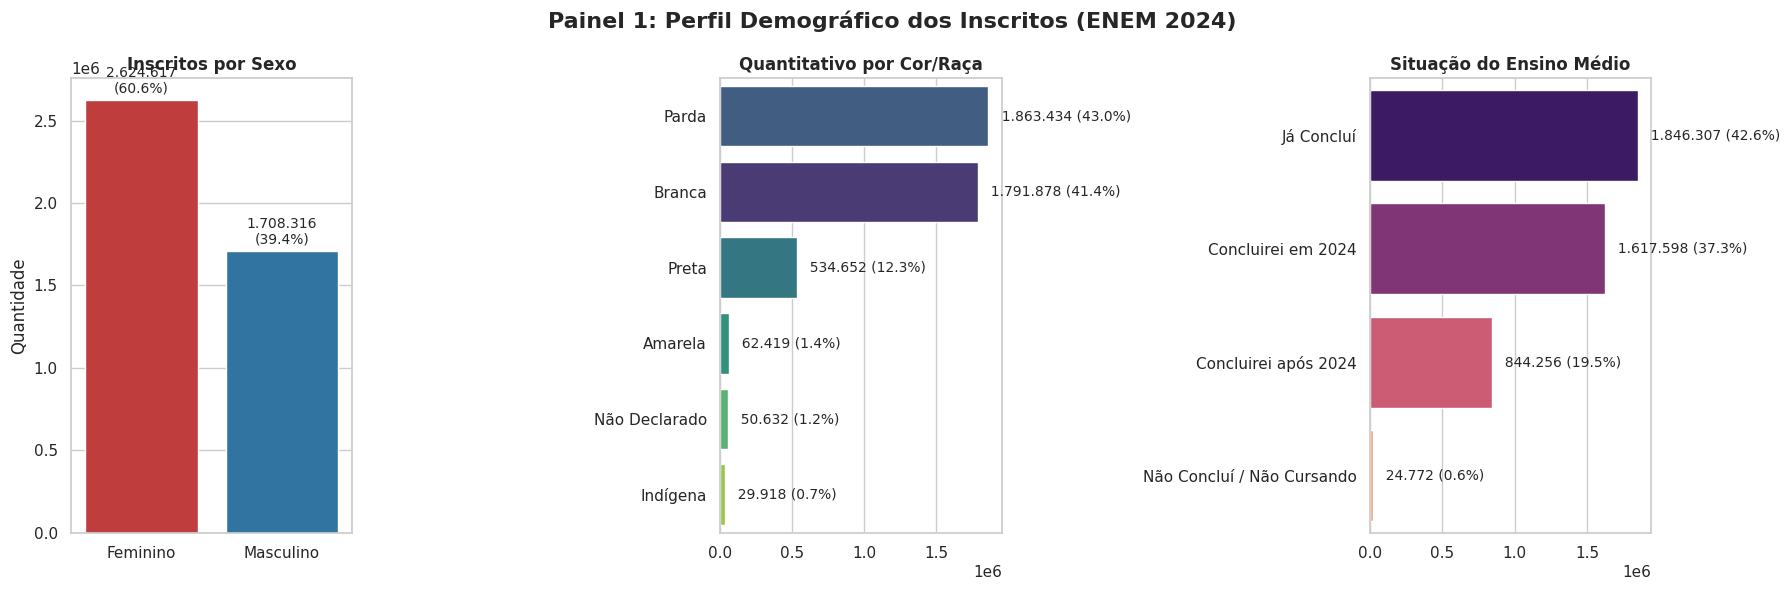

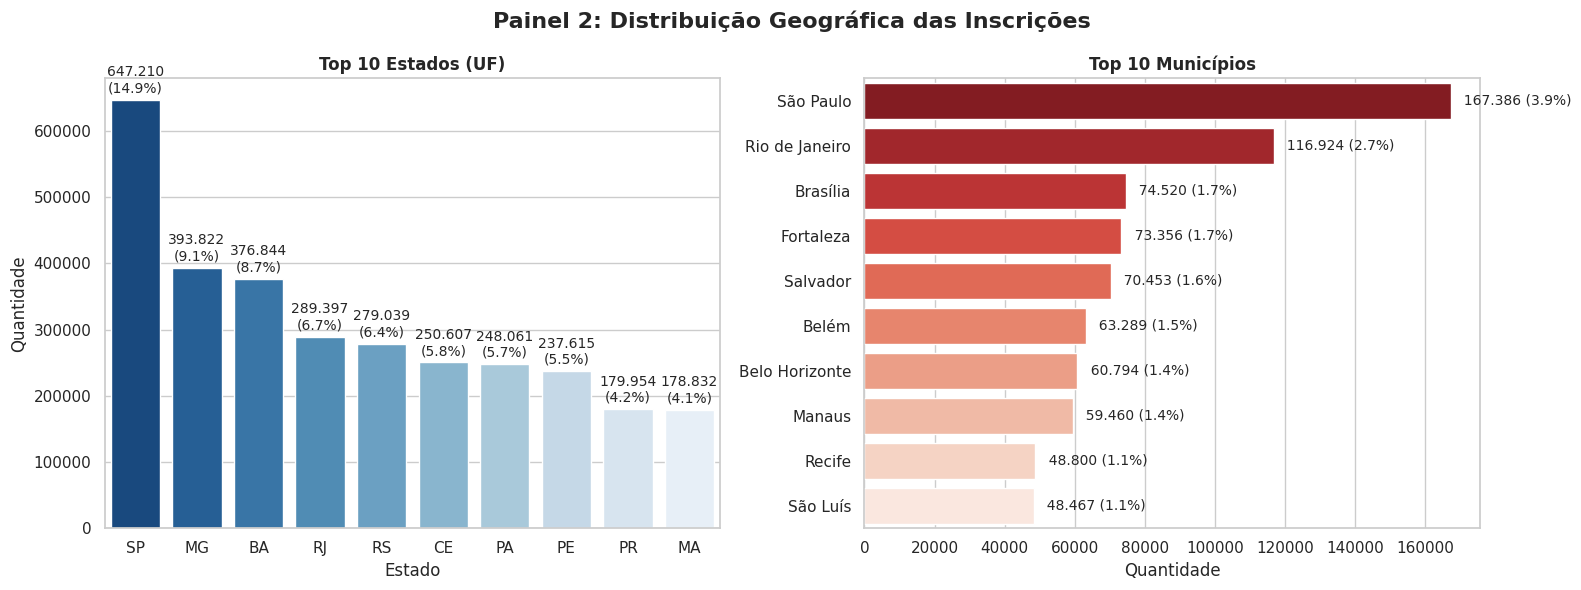

In [3]:
# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
total_alunos = len(df_part_limpo)

# 1. Função de Formatação: Número absoluto (com ponto de milhar) + Porcentagem (%)
def adicionar_valores_br(ax, total, orientacao='v'):
    for container in ax.containers:
        if orientacao == 'v':
            # Gráficos verticais: Texto em cima (quebra de linha)
            ax.bar_label(container,
                         fmt=lambda x: f"{int(x):,}".replace(",", ".") + f"\n({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)
        else:
            # Gráficos horizontais: Texto ao lado
            ax.bar_label(container,
                         fmt=lambda x: f"  {int(x):,}".replace(",", ".") + f" ({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)

# 2. Mapeamentos e Traduções para visualização
df_part_limpo['DESC_SEXO'] = df_part_limpo['TP_SEXO'].map({'M': 'Masculino', 'F': 'Feminino'})

mapa_raca = {0: 'Não Declarado', 1: 'Branca', 2: 'Preta', 3: 'Parda', 4: 'Amarela', 5: 'Indígena', 6: 'Sem Info'}
df_part_limpo['DESC_RACA'] = df_part_limpo['TP_COR_RACA'].map(mapa_raca)

mapa_conclusao = {1: 'Já Concluí', 2: 'Concluirei em 2024', 3: 'Concluirei após 2024', 4: 'Não Concluí / Não Cursando'}
df_part_limpo['DESC_CONCLUSAO'] = df_part_limpo['TP_ST_CONCLUSAO'].map(mapa_conclusao)
# ---------------------------------------------------------
# PAINEL 1: Identidade e Escolaridade (Matriz 1x3)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Painel 1: Perfil Demográfico dos Inscritos (ENEM 2024)', fontsize=16, fontweight='bold')

# A) Sexo (Cores Específicas)
paleta_sexo = {'Feminino': '#d62728', 'Masculino': '#1f77b4'} # Vermelho e Azul
sns.countplot(data=df_part_limpo, x='DESC_SEXO', hue='DESC_SEXO', palette=paleta_sexo, ax=axes[0], legend=False)
axes[0].set_title('Inscritos por Sexo', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Quantidade')
adicionar_valores_br(axes[0], total_alunos, orientacao='v')

# B) Cor/Raça
sns.countplot(data=df_part_limpo, y='DESC_RACA', hue='DESC_RACA', order=df_part_limpo['DESC_RACA'].value_counts().index, palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Quantitativo por Cor/Raça', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('')
adicionar_valores_br(axes[1], total_alunos, orientacao='h')

# C) Situação do Ensino Médio
sns.countplot(data=df_part_limpo, y='DESC_CONCLUSAO', hue='DESC_CONCLUSAO', order=df_part_limpo['DESC_CONCLUSAO'].value_counts().index, palette='magma', ax=axes[2], legend=False)
axes[2].set_title('Situação do Ensino Médio', fontweight='bold')
axes[2].set_xlabel(''); axes[2].set_ylabel('')
adicionar_valores_br(axes[2], total_alunos, orientacao='h')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PAINEL 2: Geografia e Distribuição (Matriz 1x2)
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle('Painel 2: Distribuição Geográfica das Inscrições', fontsize=16, fontweight='bold')

# A) Top 10 Estados
top_ufs = df_part_limpo['SG_UF_PROVA'].value_counts().head(10)
sns.barplot(x=top_ufs.index, y=top_ufs.values, hue=top_ufs.index, palette='Blues_r', ax=axes2[0], legend=False)
axes2[0].set_title('Top 10 Estados (UF)', fontweight='bold')
axes2[0].set_xlabel('Estado'); axes2[0].set_ylabel('Quantidade')
# Para pegar a base do Total Nacional e não dar mais de 100%, passamos o total_alunos
adicionar_valores_br(axes2[0], total_alunos, orientacao='v')

# B) Top 10 Municípios
top_cidades = df_part_limpo['NO_MUNICIPIO_PROVA'].value_counts().head(10)
sns.barplot(y=top_cidades.index, x=top_cidades.values, hue=top_cidades.index, palette='Reds_r', ax=axes2[1], legend=False)
axes2[1].set_title('Top 10 Municípios', fontweight='bold')
axes2[1].set_xlabel('Quantidade'); axes2[1].set_ylabel('')
adicionar_valores_br(axes2[1], total_alunos, orientacao='h')

plt.tight_layout()
plt.show()

## Análise Univariada: Questionário Socioeconômico (Q001 a Q008)
**Insights e Descobertas:**
* **Escolaridade dos Responsáveis:** O espelhamento dos gráficos evidencia como a formação educacional das mães (mulheres responsáveis) e dos pais (homens responsáveis) se distribui. Observar os picos em categorias como "Ensino Médio Completo" ou "Fund. Incompleto" define o capital cultural da família do candidato.
* **Adensamento Domiciliar e Renda:** A análise conjunta do número de moradores (Q005) e das faixas de renda (Q007) traça o perfil de vulnerabilidade. A esmagadora maioria concentra-se nas faixas iniciais de renda familiar (até 2 salários mínimos) e não possui renda própria, indicando dedicação exclusiva aos estudos ou desemprego. A ausência massiva de serviços domésticos terceirizados (Q008) corrobora o perfil de renda focado na base da pirâmide.

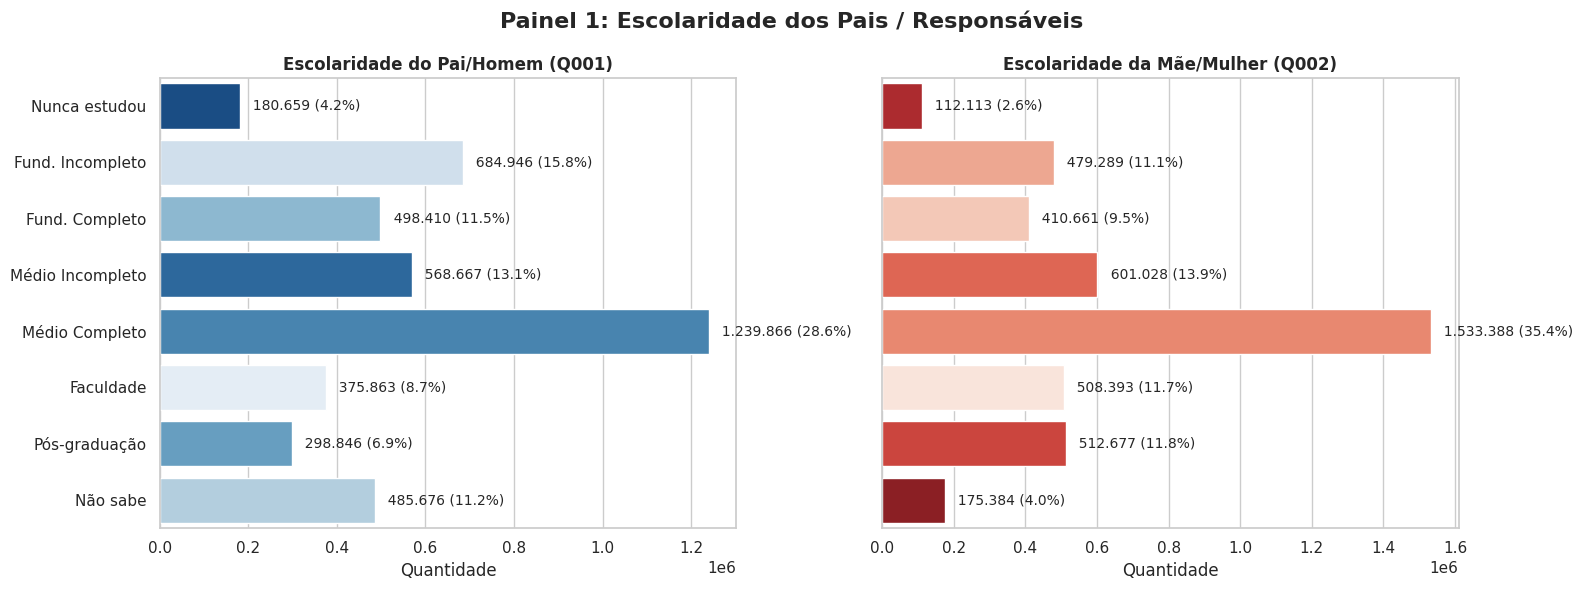

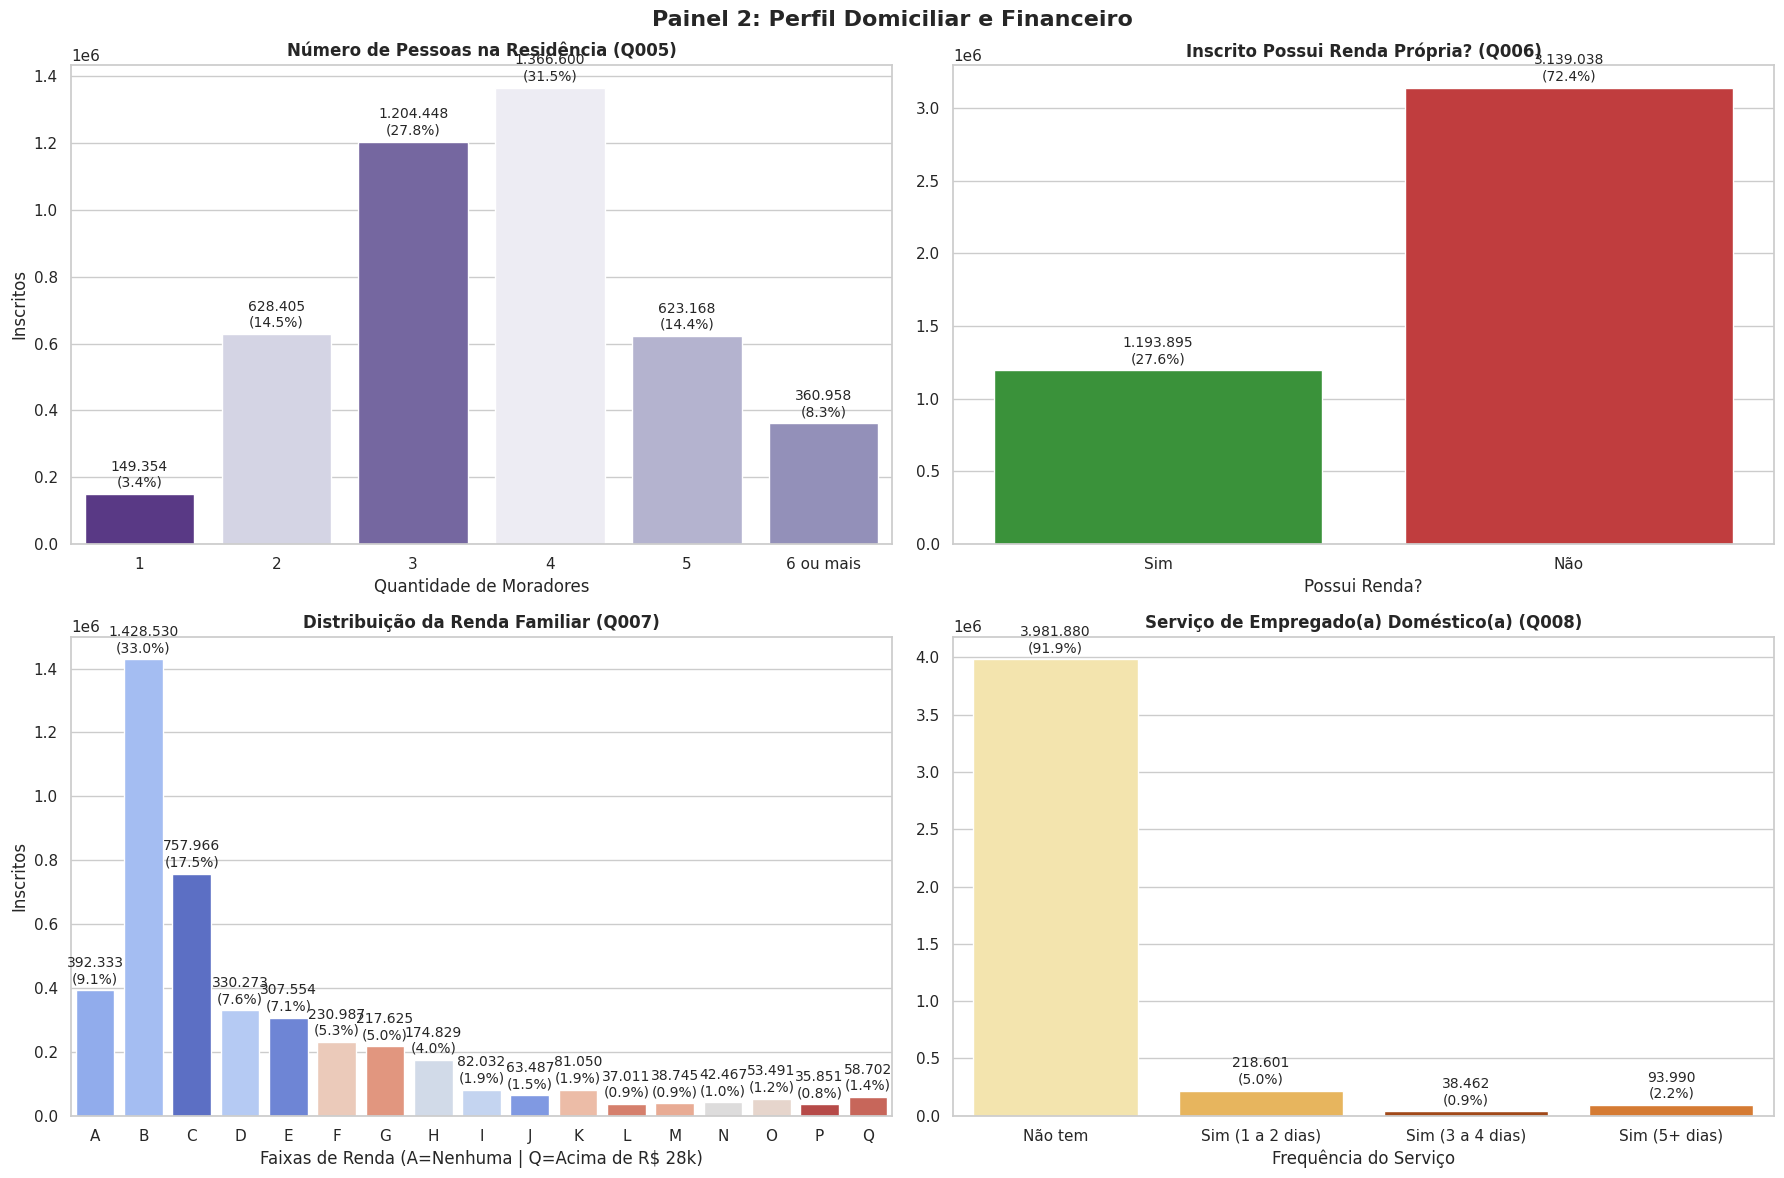

In [4]:
# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
total_alunos = len(df_part_limpo)

# 1. Função Turbinada (Número Absoluto com formatação BR + Porcentagem)
def adicionar_valores_br(ax, total, orientacao='v'):
    for container in ax.containers:
        if orientacao == 'v':
            # Gráficos verticais: Texto em cima (com quebra de linha)
            ax.bar_label(container,
                         fmt=lambda x: f"{int(x):,}".replace(",", ".") + f"\n({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)
        else:
            # Gráficos horizontais: Texto ao lado
            ax.bar_label(container,
                         fmt=lambda x: f"  {int(x):,}".replace(",", ".") + f" ({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)

# 2. Mapeamentos (Traduções do Dicionário)
mapa_escolaridade = {
    'A': 'Nunca estudou', 'B': 'Fund. Incompleto', 'C': 'Fund. Completo',
    'D': 'Médio Incompleto', 'E': 'Médio Completo', 'F': 'Faculdade',
    'G': 'Pós-graduação', 'H': 'Não sabe'
}

df_part_limpo['DESC_Q001'] = df_part_limpo['Q001'].map(mapa_escolaridade)
df_part_limpo['DESC_Q002'] = df_part_limpo['Q002'].map(mapa_escolaridade)

# Agrupando moradores
df_part_limpo['Q005_GRUPO'] = df_part_limpo['Q005'].apply(lambda x: str(x) if x < 6 else '6 ou mais')

df_part_limpo['DESC_Q006'] = df_part_limpo['Q006'].map({'A': 'Não', 'B': 'Sim'})

mapa_domestico = {
    'A': 'Não tem', 'B': 'Sim (1 a 2 dias)',
    'C': 'Sim (3 a 4 dias)', 'D': 'Sim (5+ dias)'
}
df_part_limpo['DESC_Q008'] = df_part_limpo['Q008'].map(mapa_domestico)

# ---------------------------------------------------------
# PAINEL 1: Escolaridade dos Pais (Matriz 1x2)
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig1.suptitle('Painel 1: Escolaridade dos Pais / Responsáveis', fontsize=16, fontweight='bold')

ordem_esc = ['Nunca estudou', 'Fund. Incompleto', 'Fund. Completo', 'Médio Incompleto', 'Médio Completo', 'Faculdade', 'Pós-graduação', 'Não sabe']

# Mantendo o padrão visual: Pai (Azul) e Mãe (Vermelho)
sns.countplot(data=df_part_limpo, y='DESC_Q001', hue='DESC_Q001', order=ordem_esc, palette='Blues', ax=axes1[0], legend=False)
axes1[0].set_title('Escolaridade do Pai/Homem (Q001)', fontweight='bold')
axes1[0].set_ylabel(''); axes1[0].set_xlabel('Quantidade')
adicionar_valores_br(axes1[0], total_alunos, orientacao='h')

sns.countplot(data=df_part_limpo, y='DESC_Q002', hue='DESC_Q002', order=ordem_esc, palette='Reds', ax=axes1[1], legend=False)
axes1[1].set_title('Escolaridade da Mãe/Mulher (Q002)', fontweight='bold')
axes1[1].set_ylabel(''); axes1[1].set_xlabel('Quantidade')
adicionar_valores_br(axes1[1], total_alunos, orientacao='h')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PAINEL 2: Perfil Domiciliar e Renda Familiar (Matriz 2x2)
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 12))
fig2.suptitle('Painel 2: Perfil Domiciliar e Financeiro', fontsize=16, fontweight='bold')

# A) Q005 - Número de Moradores
ordem_q005 = ['1', '2', '3', '4', '5', '6 ou mais']
sns.countplot(data=df_part_limpo, x='Q005_GRUPO', hue='Q005_GRUPO', order=ordem_q005, palette='Purples', ax=axes2[0,0], legend=False)
axes2[0,0].set_title('Número de Pessoas na Residência (Q005)', fontweight='bold')
axes2[0,0].set_xlabel('Quantidade de Moradores'); axes2[0,0].set_ylabel('Inscritos')
adicionar_valores_br(axes2[0,0], total_alunos, orientacao='v')

# B) Q006 - Possui Renda Própria
sns.countplot(data=df_part_limpo, x='DESC_Q006', hue='DESC_Q006', palette=['#2ca02c','#d62728' ], ax=axes2[0,1], legend=False)
axes2[0,1].set_title('Inscrito Possui Renda Própria? (Q006)', fontweight='bold')
axes2[0,1].set_xlabel('Possui Renda?'); axes2[0,1].set_ylabel('')
adicionar_valores_br(axes2[0,1], total_alunos, orientacao='v')

# C) Q007 - Renda Familiar (A a Q)
ordem_renda = sorted(df_part_limpo['Q007'].dropna().unique())
sns.countplot(data=df_part_limpo, x='Q007', hue='Q007', order=ordem_renda, palette='coolwarm', ax=axes2[1,0], legend=False)
axes2[1,0].set_title('Distribuição da Renda Familiar (Q007)', fontweight='bold')
axes2[1,0].set_xlabel('Faixas de Renda (A=Nenhuma | Q=Acima de R$ 28k)'); axes2[1,0].set_ylabel('Inscritos')
adicionar_valores_br(axes2[1,0], total_alunos, orientacao='v')

# D) Q008 - Empregado Doméstico
ordem_domestico = ['Não tem', 'Sim (1 a 2 dias)', 'Sim (3 a 4 dias)', 'Sim (5+ dias)']
sns.countplot(data=df_part_limpo, x='DESC_Q008', hue='DESC_Q008', order=ordem_domestico, palette='YlOrBr', ax=axes2[1,1], legend=False)
axes2[1,1].set_title('Serviço de Empregado(a) Doméstico(a) (Q008)', fontweight='bold')
axes2[1,1].set_xlabel('Frequência do Serviço'); axes2[1,1].set_ylabel('')
adicionar_valores_br(axes2[1,1], total_alunos, orientacao='v')

plt.tight_layout()
plt.show()

## Análise Univariada: Infraestrutura, Bens e Escolaridade (Q009 a Q023)
**Insights e Descobertas:**
* **Bens Básicos vs. Tecnologia:** A análise dos painéis revela que bens como Aparelho de TV e Geladeira estão quase universalizados entre os inscritos. No entanto, quando observamos os ativos tecnológicos (Q020 e Q021), nota-se uma queda drástica: quase metade da base não possui um computador/notebook em casa.
* **O Fator Escola:** O Painel 3 ilustra a realidade do ensino brasileiro. A esmagadora maioria dos candidatos cursou o Ensino Médio integralmente em escolas públicas, o que, cruzado com a falta de acesso a computadores, cria um cenário de dupla vulnerabilidade educacional que será posto à prova na análise de resultados.

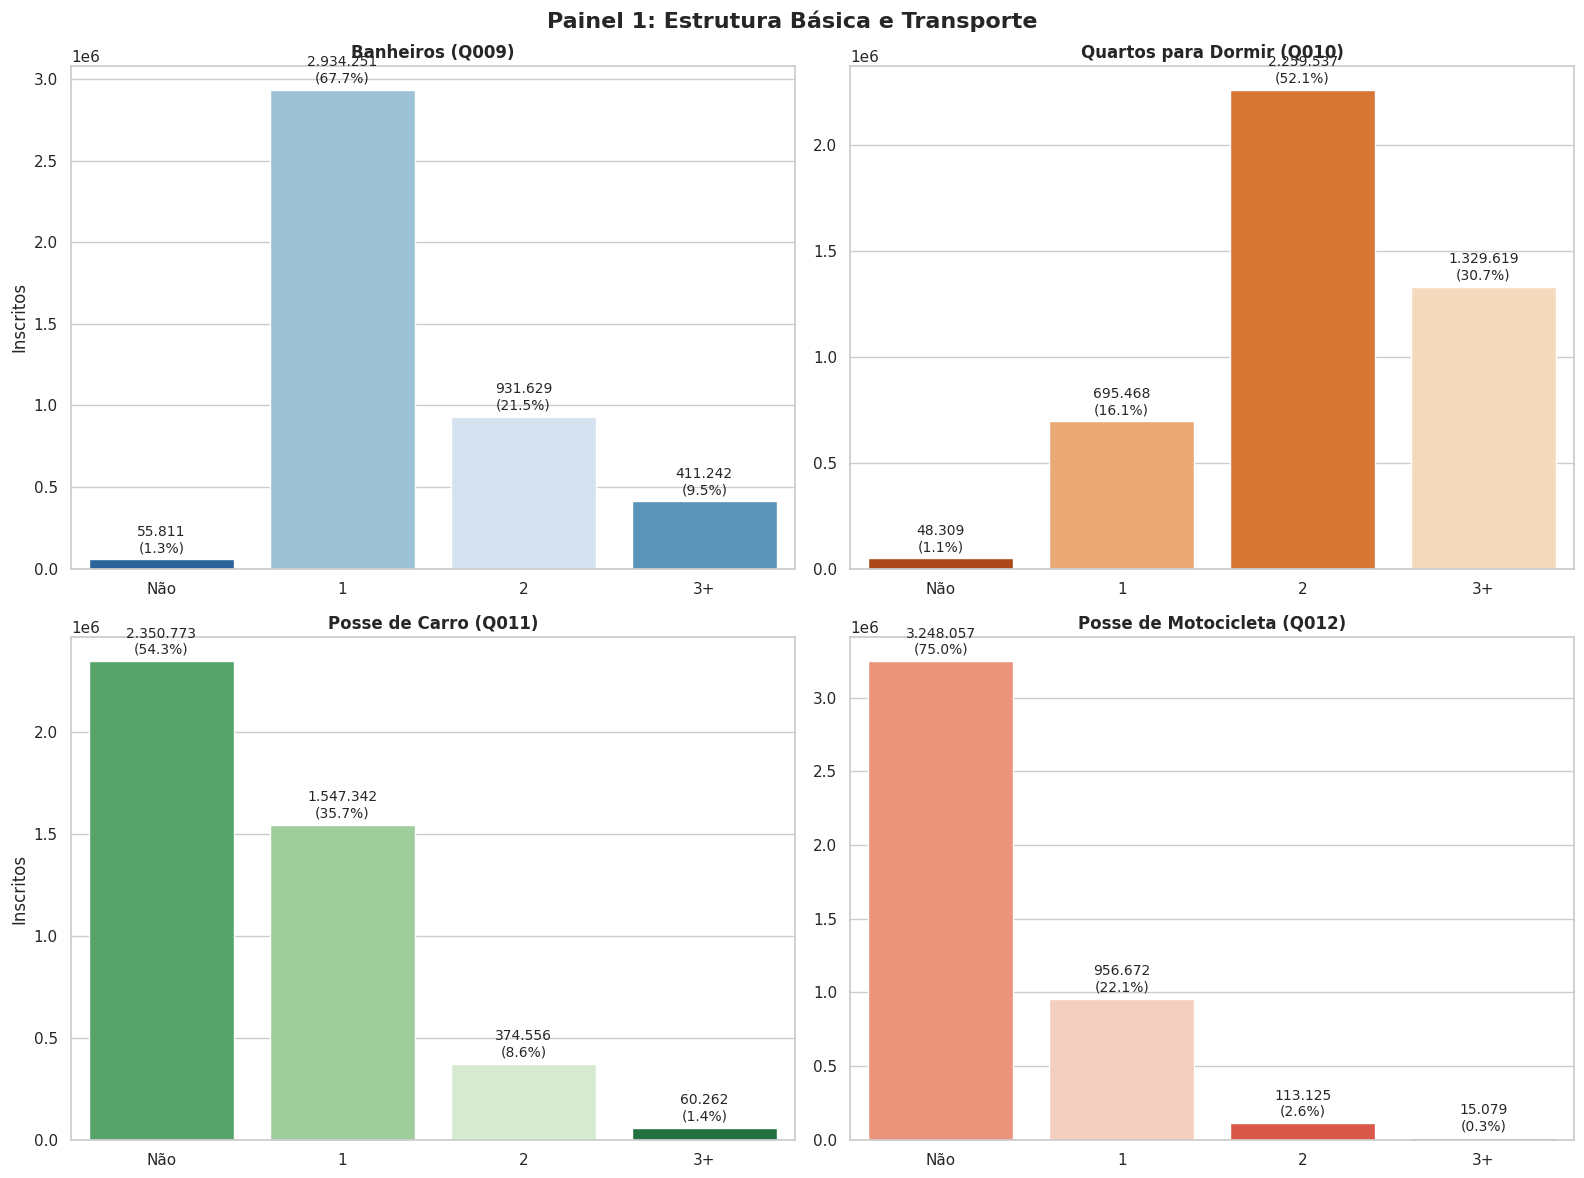

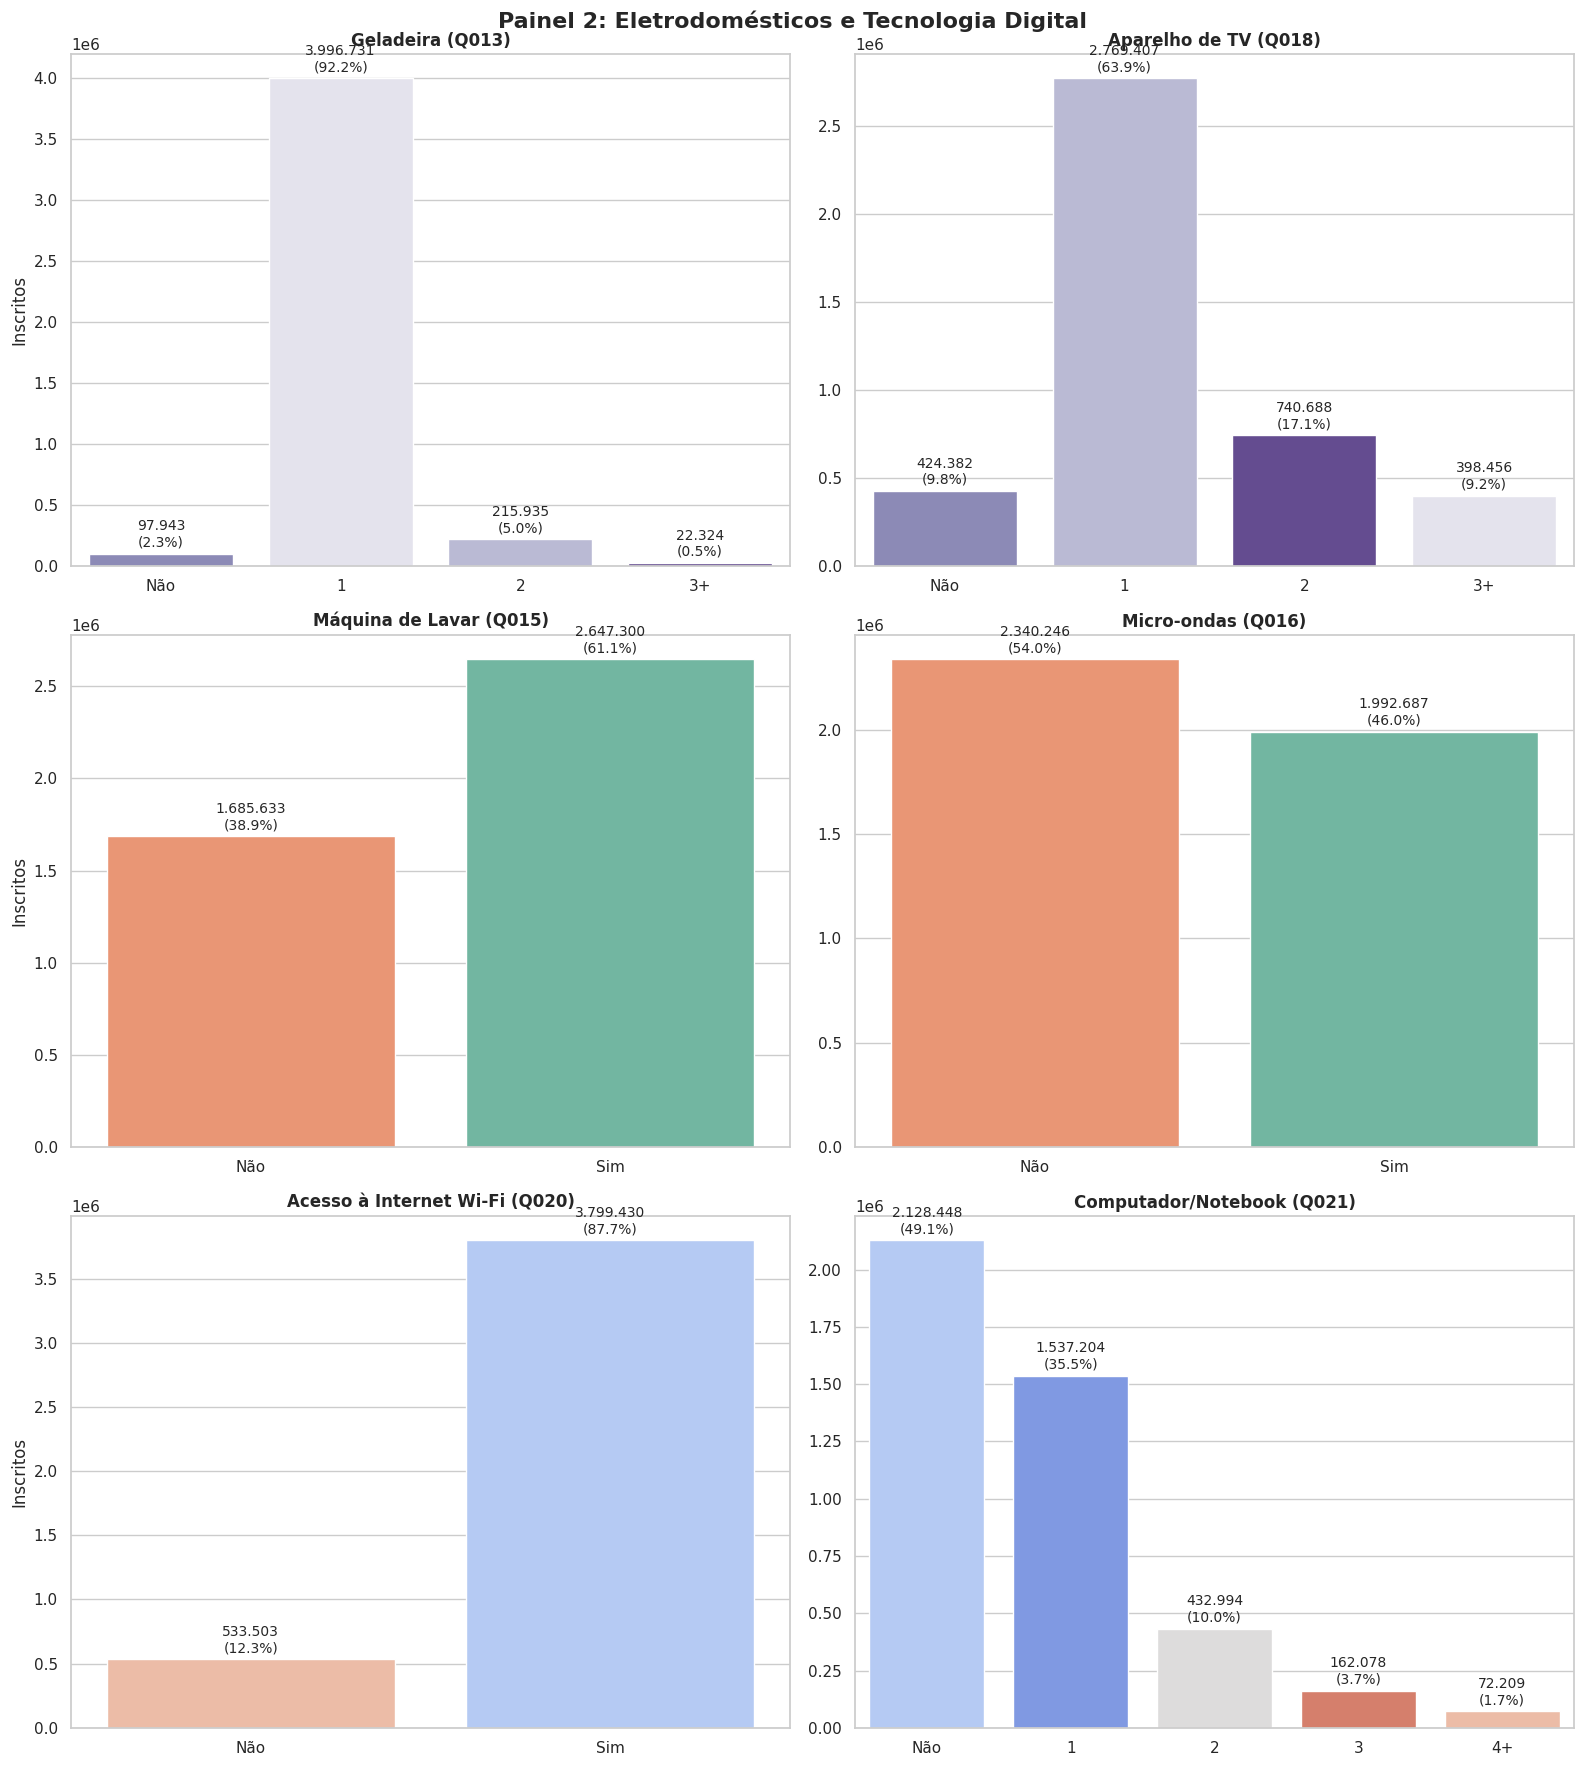

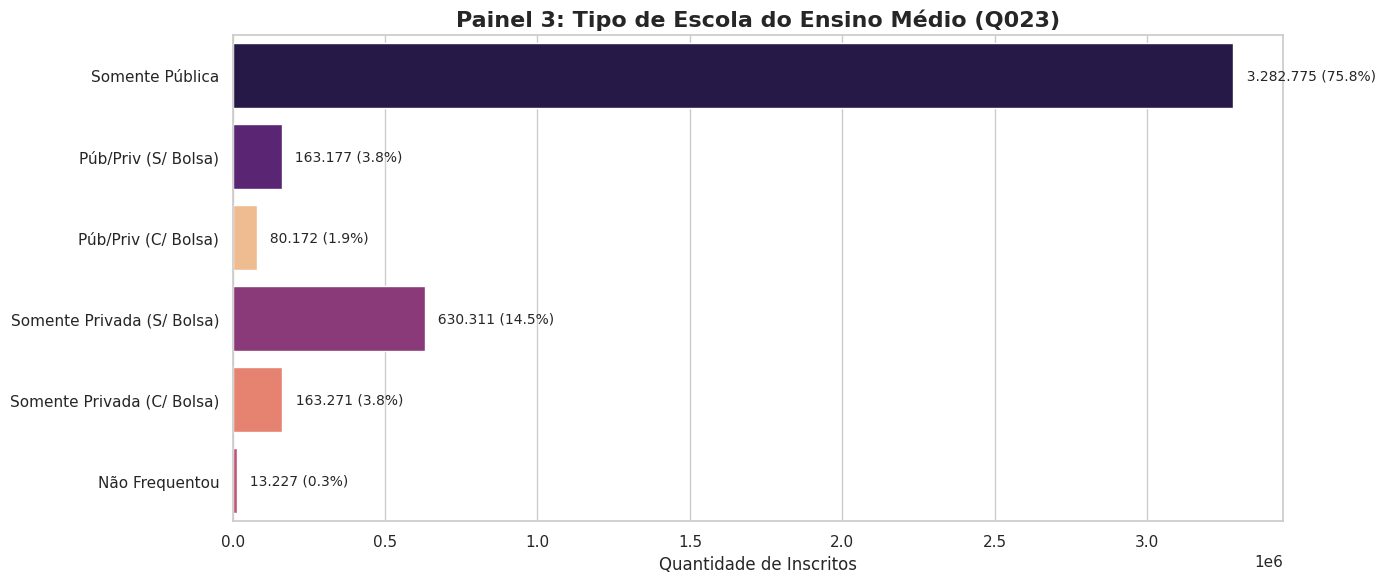

In [5]:
sns.set_theme(style="whitegrid")
total_alunos = len(df_part_limpo)

# 1. Função Turbinada (Número absoluto formatado + Porcentagem)
def adicionar_valores_br(ax, total, orientacao='v'):
    for container in ax.containers:
        if orientacao == 'v':
            # Vertical: texto em cima com quebra de linha
            ax.bar_label(container,
                         fmt=lambda x: f"{int(x):,}".replace(",", ".") + f"\n({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)
        else:
            # Horizontal: texto ao lado
            ax.bar_label(container,
                         fmt=lambda x: f"  {int(x):,}".replace(",", ".") + f" ({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)

# 2. Mapeamentos com base no Dicionário Oficial
mapa_quant_padrao = {'A': 'Não', 'B': '1', 'C': '2', 'D': '3+'}
mapa_quant_ext = {'A': 'Não', 'B': '1', 'C': '2', 'D': '3', 'E': '4+'} # Específico para PC e Celular
mapa_sim_nao = {'A': 'Não', 'B': 'Sim'}

# Aplicando as traduções
df_part_limpo['DESC_Q009'] = df_part_limpo['Q009'].map(mapa_quant_padrao) # Banheiro
df_part_limpo['DESC_Q010'] = df_part_limpo['Q010'].map(mapa_quant_padrao) # Quarto
df_part_limpo['DESC_Q011'] = df_part_limpo['Q011'].map(mapa_quant_padrao) # Carro
df_part_limpo['DESC_Q012'] = df_part_limpo['Q012'].map(mapa_quant_padrao) # Moto

df_part_limpo['DESC_Q013'] = df_part_limpo['Q013'].map(mapa_quant_padrao) # Geladeira
df_part_limpo['DESC_Q015'] = df_part_limpo['Q015'].map(mapa_sim_nao)       # Máquina de Lavar
df_part_limpo['DESC_Q016'] = df_part_limpo['Q016'].map(mapa_sim_nao)       # Micro-ondas
df_part_limpo['DESC_Q018'] = df_part_limpo['Q018'].map(mapa_quant_padrao) # TV

df_part_limpo['DESC_Q020'] = df_part_limpo['Q020'].map(mapa_sim_nao)       # Internet
df_part_limpo['DESC_Q021'] = df_part_limpo['Q021'].map(mapa_quant_ext)     # PC
df_part_limpo['DESC_Q022'] = df_part_limpo['Q022'].map(mapa_quant_ext)     # Celular

mapa_q023 = {
    'A': 'Somente Pública', 'B': 'Púb/Priv (S/ Bolsa)', 'C': 'Púb/Priv (C/ Bolsa)',
    'D': 'Somente Privada (S/ Bolsa)', 'E': 'Somente Privada (C/ Bolsa)', 'F': 'Não Frequentou'
}
df_part_limpo['DESC_Q023'] = df_part_limpo['Q023'].map(mapa_q023)

# ---------------------------------------------------------
# PAINEL 1: Estrutura Básica e Transporte (Matriz 2x2)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Painel 1: Estrutura Básica e Transporte', fontsize=16, fontweight='bold')
ordem_padrao = ['Não', '1', '2', '3+']

sns.countplot(data=df_part_limpo, x='DESC_Q009', hue='DESC_Q009', order=ordem_padrao, palette='Blues', ax=axes[0,0], legend=False)
axes[0,0].set_title('Banheiros (Q009)', fontweight='bold')
axes[0,0].set_ylabel('Inscritos'); axes[0,0].set_xlabel('')
adicionar_valores_br(axes[0,0], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q010', hue='DESC_Q010', order=ordem_padrao, palette='Oranges', ax=axes[0,1], legend=False)
axes[0,1].set_title('Quartos para Dormir (Q010)', fontweight='bold')
axes[0,1].set_ylabel(''); axes[0,1].set_xlabel('')
adicionar_valores_br(axes[0,1], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q011', hue='DESC_Q011', order=ordem_padrao, palette='Greens', ax=axes[1,0], legend=False)
axes[1,0].set_title('Posse de Carro (Q011)', fontweight='bold')
axes[1,0].set_ylabel('Inscritos'); axes[1,0].set_xlabel('')
adicionar_valores_br(axes[1,0], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q012', hue='DESC_Q012', order=ordem_padrao, palette='Reds', ax=axes[1,1], legend=False)
axes[1,1].set_title('Posse de Motocicleta (Q012)', fontweight='bold')
axes[1,1].set_ylabel(''); axes[1,1].set_xlabel('')
adicionar_valores_br(axes[1,1], total_alunos, orientacao='v')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PAINEL 2: Eletrodomésticos e Tecnologia Digital (Matriz 3x2)
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(3, 2, figsize=(16, 18))
fig2.suptitle('Painel 2: Eletrodomésticos e Tecnologia Digital', fontsize=16, fontweight='bold')

ordem_ext = ['Não', '1', '2', '3', '4+']
ordem_sim_nao = ['Não', 'Sim']

sns.countplot(data=df_part_limpo, x='DESC_Q013', hue='DESC_Q013', order=ordem_padrao, palette='Purples', ax=axes2[0,0], legend=False)
axes2[0,0].set_title('Geladeira (Q013)', fontweight='bold')
axes2[0,0].set_ylabel('Inscritos'); axes2[0,0].set_xlabel('')
adicionar_valores_br(axes2[0,0], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q018', hue='DESC_Q018', order=ordem_padrao, palette='Purples', ax=axes2[0,1], legend=False)
axes2[0,1].set_title('Aparelho de TV (Q018)', fontweight='bold')
axes2[0,1].set_ylabel(''); axes2[0,1].set_xlabel('')
adicionar_valores_br(axes2[0,1], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q015', hue='DESC_Q015', order=ordem_sim_nao, palette='Set2', ax=axes2[1,0], legend=False)
axes2[1,0].set_title('Máquina de Lavar (Q015)', fontweight='bold')
axes2[1,0].set_ylabel('Inscritos'); axes2[1,0].set_xlabel('')
adicionar_valores_br(axes2[1,0], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q016', hue='DESC_Q016', order=ordem_sim_nao, palette='Set2', ax=axes2[1,1], legend=False)
axes2[1,1].set_title('Micro-ondas (Q016)', fontweight='bold')
axes2[1,1].set_ylabel(''); axes2[1,1].set_xlabel('')
adicionar_valores_br(axes2[1,1], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q020', hue='DESC_Q020', order=ordem_sim_nao, palette='coolwarm', ax=axes2[2,0], legend=False)
axes2[2,0].set_title('Acesso à Internet Wi-Fi (Q020)', fontweight='bold')
axes2[2,0].set_ylabel('Inscritos'); axes2[2,0].set_xlabel('')
adicionar_valores_br(axes2[2,0], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q021', hue='DESC_Q021', order=ordem_ext, palette='coolwarm', ax=axes2[2,1], legend=False)
axes2[2,1].set_title('Computador/Notebook (Q021)', fontweight='bold')
axes2[2,1].set_ylabel(''); axes2[2,1].set_xlabel('')
adicionar_valores_br(axes2[2,1], total_alunos, orientacao='v')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PAINEL 3: Tipo de Escola do Ensino Médio (Q023)
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
ordem_escola = ['Somente Pública', 'Púb/Priv (S/ Bolsa)', 'Púb/Priv (C/ Bolsa)',
                'Somente Privada (S/ Bolsa)', 'Somente Privada (C/ Bolsa)', 'Não Frequentou']

ax_escola = sns.countplot(data=df_part_limpo, y='DESC_Q023', hue='DESC_Q023', order=ordem_escola, palette='magma', legend=False)
plt.title('Painel 3: Tipo de Escola do Ensino Médio (Q023)', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Inscritos', fontsize=12)
plt.ylabel('')

# Passando orientacao='h' para o gráfico horizontal
adicionar_valores_br(ax_escola, total_alunos, orientacao='h')

plt.tight_layout()
plt.show()

## Visão Geral de Resultados e Análise de Extremos (Outliers)
**Insights e Descobertas:**
* **A Preservação dos Outliers:** Optamos deliberadamente por não aplicar filtros de corte populacional (ex: excluir cidades com menos de 30 alunos). Manter a granularidade total permite o mapeamento de anomalias estatísticas legítimas — municípios minúsculos que alcançam o topo do ranking impulsionados por desempenhos individuais excepcionais ("outliers positivos").
* **O Contraste Nacional:** O ranking unificado das maiores e menores médias gerais do país expõe a amplitude da desigualdade educacional, servindo como base sólida para correlacionarmos, no passo final, essas notas com os indicadores de exclusão digital mapeados anteriormente.

In [6]:
# 1. Filtrar apenas alunos válidos
# Usando as flags para garantir que o aluno esteve presente e teve a redação corrigida
df_res_validos = df_res_limpo[(df_res_limpo['TP_PRESENCA_MT'] == 1) & (df_res_limpo['TP_STATUS_REDACAO'] == 1)].copy()

# 2. Agrupar os Resultados por Município (TODAS as competências)
df_ranking = df_res_validos.groupby(['CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'SG_UF_PROVA']).agg(
    TOTAL_ALUNOS=('CO_MUNICIPIO_PROVA', 'count'),
    MEDIA_CN=('NU_NOTA_CN', 'mean'),
    MEDIA_CH=('NU_NOTA_CH', 'mean'),
    MEDIA_LC=('NU_NOTA_LC', 'mean'),
    MEDIA_MT=('NU_NOTA_MT', 'mean'),
    MEDIA_REDACAO=('NU_NOTA_REDACAO', 'mean')
).reset_index()

# 3. Engenharia de Variável: Média Geral da Cidade
# Soma as 5 disciplinas e divide por 5 para criar um indicador único de desempenho
df_ranking['MEDIA_GERAL'] = df_ranking[['MEDIA_CN', 'MEDIA_CH', 'MEDIA_LC', 'MEDIA_MT', 'MEDIA_REDACAO']].mean(axis=1)

# 4. Extraindo os Extremos Absolutos (Focando na Média Geral)
# Sem filtro de corte populacional para preservação de anomalias/gênios
top_10_cidades = df_ranking.nlargest(10, 'MEDIA_GERAL')
bottom_10_cidades = df_ranking.nsmallest(10, 'MEDIA_GERAL')

# Formatação visual do output para melhor leitura
colunas_exibicao = ['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', 'TOTAL_ALUNOS', 'MEDIA_GERAL', 'MEDIA_REDACAO', 'MEDIA_MT', 'MEDIA_CN', 'MEDIA_CH', 'MEDIA_LC']

print("TOP 10 CIDADES COM AS MAIORES MÉDIAS GERAIS:")
display(top_10_cidades[colunas_exibicao])

print("\n" + "="*100 + "\n")

print("TOP 10 CIDADES COM AS MENORES MÉDIAS GERAIS:")
display(bottom_10_cidades[colunas_exibicao])

TOP 10 CIDADES COM AS MAIORES MÉDIAS GERAIS:


,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TOTAL_ALUNOS,MEDIA_GERAL,MEDIA_REDACAO,MEDIA_MT,MEDIA_CN,MEDIA_CH,MEDIA_LC
1595,Veranópolis,RS,335,602.264716,766.507463,592.291642,529.585075,562.299104,560.640299
1339,Valinhos,SP,1604,600.107070,701.658354,610.262032,551.297943,569.483541,567.833479
938,Itaúna,MG,1026,600.015828,740.740741,602.707310,531.558674,563.610331,561.462086
1317,São José dos Campos,SP,9651,597.319575,710.767796,605.027634,541.071423,564.221936,565.509087
1541,Lajeado,RS,1043,597.278063,724.774688,599.534708,533.604314,564.587728,563.888878
1083,Vitória,ES,7027,595.714831,724.044400,591.439192,539.922954,562.709606,560.458005
1110,Niterói,RJ,10321,595.471832,730.200562,589.565720,533.695020,562.274838,561.623021
1029,Timóteo,MG,1185,594.889671,735.054852,593.347932,532.245823,558.496118,555.303629
1343,Vinhedo,SP,989,594.590637,705.763397,599.031648,541.702123,560.759151,565.696866
1493,Arroio do Meio,RS,136,594.394706,727.500000,591.980882,537.841176,554.300000,560.351471




TOP 10 CIDADES COM AS MENORES MÉDIAS GERAIS:


,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TOTAL_ALUNOS,MEDIA_GERAL,MEDIA_REDACAO,MEDIA_MT,MEDIA_CN,MEDIA_CH,MEDIA_LC
69,Japurá,AM,35,435.321714,474.285714,429.131429,423.442857,406.845714,442.902857
49,Benjamin Constant,AM,483,445.428696,493.374741,437.139337,430.763561,421.151967,444.713872
94,Tonantins,AM,109,448.453578,510.642202,428.453211,426.841284,424.440367,451.890826
76,Maraã,AM,74,455.459730,496.216216,438.272973,442.775676,439.670270,460.363514
86,Santa Isabel do Rio Negro,AM,83,457.423855,508.192771,429.510843,450.742169,438.691566,459.981928
81,Novo Aripuanã,AM,182,458.347143,510.769231,445.196703,441.743407,438.181868,455.844505
163,Prainha,PA,319,459.376113,547.398119,441.235110,439.387461,421.451724,447.408150
45,Atalaia do Norte,AM,106,460.674906,547.169811,435.033019,421.439623,433.321698,466.410377
87,Santo Antônio do Içá,AM,226,461.432212,537.876106,441.627876,435.942035,438.703982,453.011062
95,Uarini,AM,54,461.932222,516.666667,447.529630,433.774074,444.079630,467.611111


In [7]:
# ---------------------------------------------------------
# PASSO 1: Preparar Indicadores Socioeconômicos (Flags Binárias)
# ---------------------------------------------------------
# 1 = Não tem internet (A) / 0 = Tem
df_part_limpo['FLAG_SEM_INTERNET'] = np.where(df_part_limpo['Q020'] == 'A', 1, 0)

# 1 = Não tem computador (A) / 0 = Tem
df_part_limpo['FLAG_SEM_PC'] = np.where(df_part_limpo['Q021'] == 'A', 1, 0)

# 1 = Estudou SOMENTE em escola pública (A) / 0 = Outros
df_part_limpo['FLAG_ESCOLA_PUBLICA'] = np.where(df_part_limpo['Q023'] == 'A', 1, 0)

# ---------------------------------------------------------
# PASSO 2: Agrupar Participantes por Cidade
# ---------------------------------------------------------

df_cidades_perfil = df_part_limpo.groupby(['CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'SG_UF_PROVA']).agg(
    TOTAL_INSCRITOS=('CO_MUNICIPIO_PROVA', 'count'),
    PERC_SEM_INTERNET=('FLAG_SEM_INTERNET', 'mean'), # A média de zeros e uns dá a porcentagem (0.0 a 1.0)
    PERC_SEM_PC=('FLAG_SEM_PC', 'mean'),
    PERC_ESCOLA_PUBLICA=('FLAG_ESCOLA_PUBLICA', 'mean')
).reset_index()

# Multiplicando por 100 para facilitar a leitura percentual
df_cidades_perfil['PERC_SEM_INTERNET'] *= 100
df_cidades_perfil['PERC_SEM_PC'] *= 100
df_cidades_perfil['PERC_ESCOLA_PUBLICA'] *= 100

# ---------------------------------------------------------
# PASSO 3: Agrupar Resultados (Notas e Abstenção) por Cidade
# ---------------------------------------------------------

# Filtrar apenas quem teve as notas validadas (Para não derrubar a média com zeros de faltantes)
df_res_presentes = df_res_limpo[(df_res_limpo['TP_PRESENCA_MT'] == 1) & (df_res_limpo['TP_STATUS_REDACAO'] == 1)].copy()

df_cidades_notas = df_res_presentes.groupby('CO_MUNICIPIO_PROVA').agg(
    TOTAL_PRESENTES=('CO_MUNICIPIO_PROVA', 'count'),
    MEDIA_CN=('NU_NOTA_CN', 'mean'),
    MEDIA_CH=('NU_NOTA_CH', 'mean'),
    MEDIA_LC=('NU_NOTA_LC', 'mean'),
    MEDIA_MT=('NU_NOTA_MT', 'mean'),
    MEDIA_REDACAO=('NU_NOTA_REDACAO', 'mean')
).reset_index()

# Criando a Média Geral da Cidade
df_cidades_notas['MEDIA_GERAL'] = df_cidades_notas[['MEDIA_CN', 'MEDIA_CH', 'MEDIA_LC', 'MEDIA_MT', 'MEDIA_REDACAO']].mean(axis=1)

# ---------------------------------------------------------
# PASSO 4: Merge das Bases (INNER JOIN)
# ---------------------------------------------------------
df_master_cidades = pd.merge(df_cidades_perfil, df_cidades_notas, on='CO_MUNICIPIO_PROVA', how='inner')

# Calculando a Taxa de Abstenção da Cidade
df_master_cidades['TAXA_ABSTENCAO'] = (1 - (df_master_cidades['TOTAL_PRESENTES'] / df_master_cidades['TOTAL_INSCRITOS'])) * 100

print(f"Total de Municípios analisados (Sem filtros populacionais): {len(df_master_cidades)}\n")

# Visão final do Dataset preparado
colunas_visao = ['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', 'TOTAL_INSCRITOS', 'PERC_SEM_PC', 'PERC_ESCOLA_PUBLICA', 'MEDIA_GERAL', 'TAXA_ABSTENCAO']
display(df_master_cidades[colunas_visao].head())

Total de Municípios analisados (Sem filtros populacionais): 1753



,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TOTAL_INSCRITOS,PERC_SEM_PC,PERC_ESCOLA_PUBLICA,MEDIA_GERAL,TAXA_ABSTENCAO
0,Alta Floresta D'Oeste,RO,471,54.140127,98.513800,528.108469,34.819533
1,Ariquemes,RO,2505,47.105788,88.662675,536.427346,40.439122
2,Cacoal,RO,2497,40.728875,73.127753,539.397713,34.160993
3,Cerejeiras,RO,414,47.342995,95.652174,519.465600,39.613527
4,Colorado do Oeste,RO,431,31.786543,96.751740,537.969703,29.698376


In [8]:
# Força o Pandas a mostrar todas as colunas sem esconder nada
pd.set_option('display.max_columns', None)

print("VISÃO GERAL DE TODOS OS ATRIBUTOS DA BASE CONSOLIDADA:")
# Chamamos o df_master_cidades inteiro, sem filtrar colchetes
display(df_master_cidades.head())

VISÃO GERAL DE TODOS OS ATRIBUTOS DA BASE CONSOLIDADA:


,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TOTAL_INSCRITOS,PERC_SEM_INTERNET,PERC_SEM_PC,PERC_ESCOLA_PUBLICA,TOTAL_PRESENTES,MEDIA_CN,MEDIA_CH,MEDIA_LC,MEDIA_MT,MEDIA_REDACAO,MEDIA_GERAL,TAXA_ABSTENCAO
0,1100015,Alta Floresta D'Oeste,RO,471,4.670913,54.140127,98.513800,307,473.418567,487.769707,503.437459,490.770033,685.146580,528.108469,34.819533
1,1100023,Ariquemes,RO,2505,10.698603,47.105788,88.662675,1492,488.580027,502.924330,517.900804,509.755697,662.975871,536.427346,40.439122
2,1100049,Cacoal,RO,2497,6.127353,40.728875,73.127753,1644,492.673601,508.075182,520.778954,519.025304,656.435523,539.397713,34.160993
3,1100056,Cerejeiras,RO,414,4.589372,47.342995,95.652174,250,475.308000,490.324000,506.243600,482.172400,643.280000,519.465600,39.613527
4,1100064,Colorado do Oeste,RO,431,3.480278,31.786543,96.751740,303,492.881188,501.965017,518.929043,506.502310,669.570957,537.969703,29.698376


## Overview de Resultados: Distribuição, Outliers e Correlação

**Insights e Descobertas:**
* **Distribuição e Outliers (Boxplot):** A visualização em caixas evidencia que a Redação possui a maior dispersão de notas (com uma base expressiva de notas zero/baixas), enquanto as provas objetivas possuem um comportamento mais contido. Os pontos fora dos "bigodes" do gráfico provam a existência de *outliers* (desempenhos individuais extremos) que não devem ser descartados.
* **Correlação não é Causalidade:** O Mapa de Calor (Heatmap) revela uma forte correlação linear (0.76) entre Ciências Humanas e Linguagens, indicando que a proficiência em leitura afeta ambas as provas simultaneamente.
* **Avaliação Global dos Extremos:** Ao calcularmos a "Média Geral" (unificando as 5 notas), conseguimos extrair o ranking absoluto. Identificamos tanto os municípios com os "gênios" isolados (maiores notas máximas), quanto os municípios com maior defasagem global (menores médias gerais).

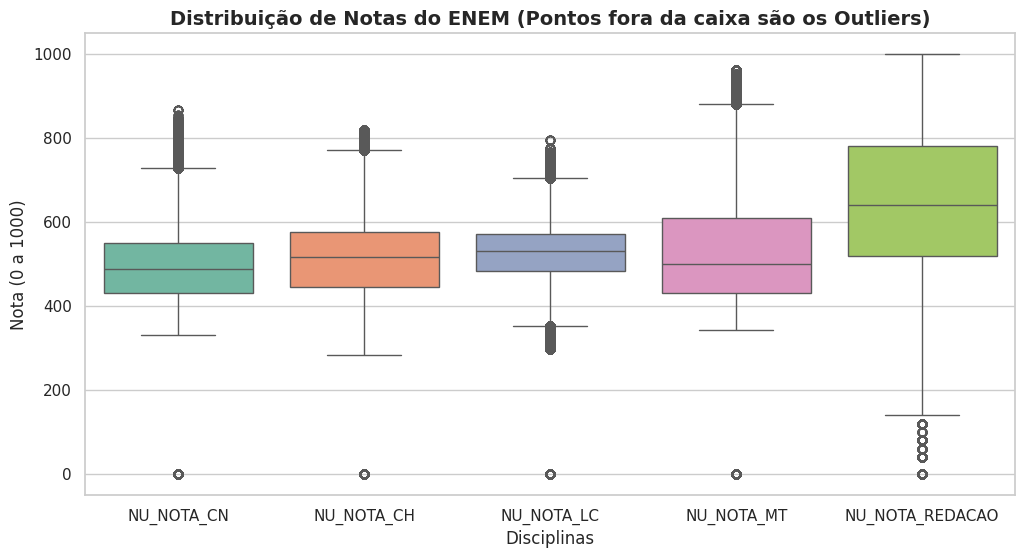


--- CAÇANDO OUTLIERS (GÊNIOS): Top 10 Cidades com as Maiores Notas MÁXIMAS (Média Geral) ---


,SG_UF_PROVA,NO_MUNICIPIO_PROVA,NOTA_MAXIMA_ISOLADA
1212,RJ,Macaé,859.80
1698,SP,São José dos Campos,852.94
1100,PI,Teresina,851.05
1702,SP,São Paulo,849.72
1706,SP,Taboão da Serra,847.90
958,PB,João Pessoa,846.24
447,GO,Goiânia,845.32
1089,PI,Parnaíba,844.86
1049,PE,Recife,844.56
551,MA,São Luís,844.46



--- Top 10 Cidades com as Menores Médias Gerais ---


,SG_UF_PROVA,NO_MUNICIPIO_PROVA,MEDIA_GLOBAL_CIDADE
71,AM,Japurá,343.658155
57,AM,Canutama,423.516622
70,AM,Itamarati,423.554615
51,AM,Benjamin Constant,424.870848
78,AM,Maraã,426.680099
96,AM,Tonantins,428.924327
56,AM,Caapiranga,429.002733
72,AM,Jutaí,434.720965
83,AM,Novo Aripuanã,436.035374
97,AM,Uarini,436.964491


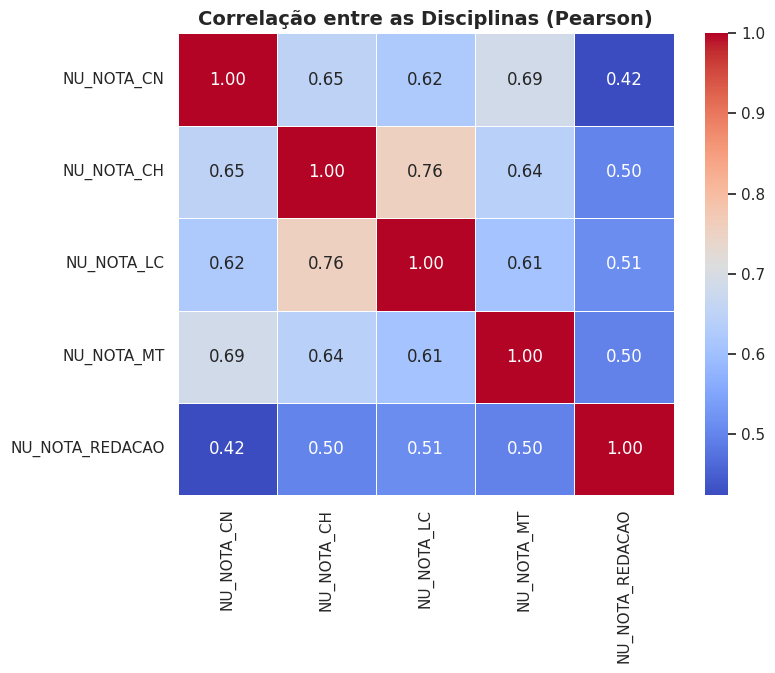

In [9]:
sns.set_theme(style="whitegrid")

# 1. Definindo as colunas de notas
notas_cols = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

# Criando a Média Geral por Aluno (Para podermos avaliar todas as competências juntas)
df_res_limpo['MEDIA_GERAL_ALUNO'] = df_res_limpo[notas_cols].mean(axis=1)

# ---------------------------------------------------------
# GRÁFICO 1: Distribuição e Outliers (Boxplot)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_res_limpo[notas_cols], palette='Set2')
plt.title('Distribuição de Notas do ENEM (Pontos fora da caixa são os Outliers)', fontsize=14, fontweight='bold')
plt.ylabel('Nota (0 a 1000)')
plt.xlabel('Disciplinas')
plt.show()

# ---------------------------------------------------------
# TABELA 1: Caçando os Maiores Outliers (Gênios Isolados)
# ---------------------------------------------------------
print("\n--- CAÇANDO OUTLIERS (GÊNIOS): Top 10 Cidades com as Maiores Notas MÁXIMAS (Média Geral) ---")
# Agrupamos por cidade pegando a nota MÁXIMA que algum aluno tirou lá dentro
cidades_outliers_altos = df_res_limpo.groupby(['SG_UF_PROVA', 'NO_MUNICIPIO_PROVA'])['MEDIA_GERAL_ALUNO'].max().reset_index()
cidades_outliers_altos = cidades_outliers_altos.sort_values(by='MEDIA_GERAL_ALUNO', ascending=False).head(10)
# Renomeando para ficar claro na apresentação
cidades_outliers_altos.rename(columns={'MEDIA_GERAL_ALUNO': 'NOTA_MAXIMA_ISOLADA'}, inplace=True)
display(cidades_outliers_altos)

# ---------------------------------------------------------
# TABELA 2: Municípios com as Menores Médias Globais
# ---------------------------------------------------------
print("\n--- Top 10 Cidades com as Menores Médias Gerais ---")
# Aqui pegamos a MÉDIA da cidade para ver o desempenho real do município
cidades_outliers_baixos = df_res_limpo.groupby(['SG_UF_PROVA', 'NO_MUNICIPIO_PROVA'])['MEDIA_GERAL_ALUNO'].mean().reset_index()
cidades_outliers_baixos = cidades_outliers_baixos.sort_values(by='MEDIA_GERAL_ALUNO', ascending=True).head(10)
cidades_outliers_baixos.rename(columns={'MEDIA_GERAL_ALUNO': 'MEDIA_GLOBAL_CIDADE'}, inplace=True)
display(cidades_outliers_baixos)

# ---------------------------------------------------------
# GRÁFICO 2: Heatmap de Correlação
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
correlacao_notas = df_res_limpo[notas_cols].corr()
sns.heatmap(correlacao_notas, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação entre as Disciplinas (Pearson)', fontsize=14, fontweight='bold')
plt.show()

## Impacto da Exclusão no Desempenho Global


**Insights e Descobertas:**
* **Manutenção Extrema:** Seguindo a premissa arquitetural de preservação de *outliers*, nenhum filtro de volume populacional foi aplicado. Isso garante que a análise reflita o impacto tecnológico puro, independentemente do tamanho do município.
* **Boxplot:** A plotagem da Média Geral revela um abismo estatístico. Os municípios da "Elite Digital" operam em um quartil de notas drasticamente superior, com os *outliers* negativos das cidades conectadas ainda sendo superiores à mediana das cidades excluídas.
* **Impacto Multidisciplinar:** A comparação com a Média Nacional nas cinco áreas do conhecimento corrobora a tese de que a exclusão digital não afeta apenas disciplinas técnicas (Matemática e Ciências da Natureza), mas cria um déficit cognitivo generalizado, puxando para baixo até mesmo as competências de Linguagens e Redação.

>>> TOP 5 CIDADES COM MAIOR EXCLUSÃO DIGITAL <<<


,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TOTAL_INSCRITOS,INDICE_EXCLUSAO,MEDIA_GERAL
48,Barreirinha,AM,839,89.272944,465.905187
69,Japurá,AM,171,89.181287,435.321714
49,Benjamin Constant,AM,1009,88.206145,445.428696
33,Porto Walter,AC,197,83.502538,464.254000
41,Alvarães,AM,288,83.333333,468.935267


/tmp/ipykernel_7652/1289970148.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.boxplot(data=df_extremos, x='PERFIL', y='MEDIA_GERAL', palette=['#d62728', '#1f77b4'])


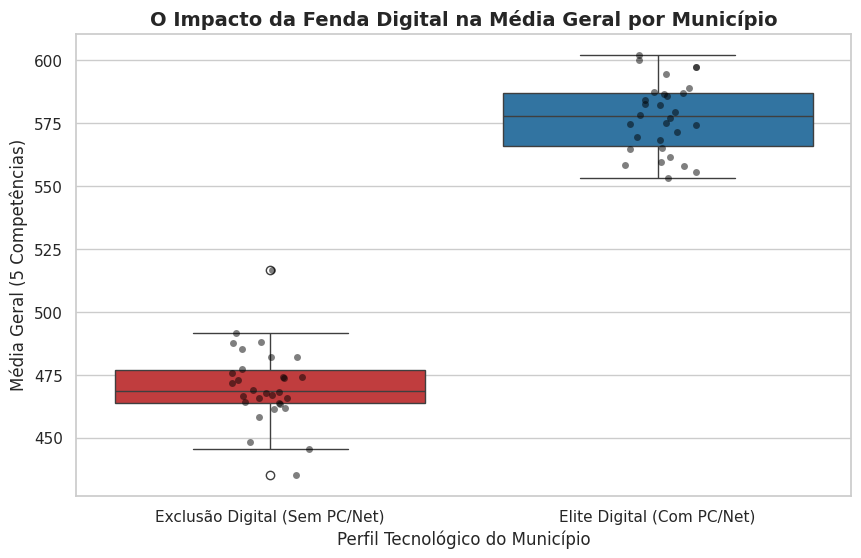

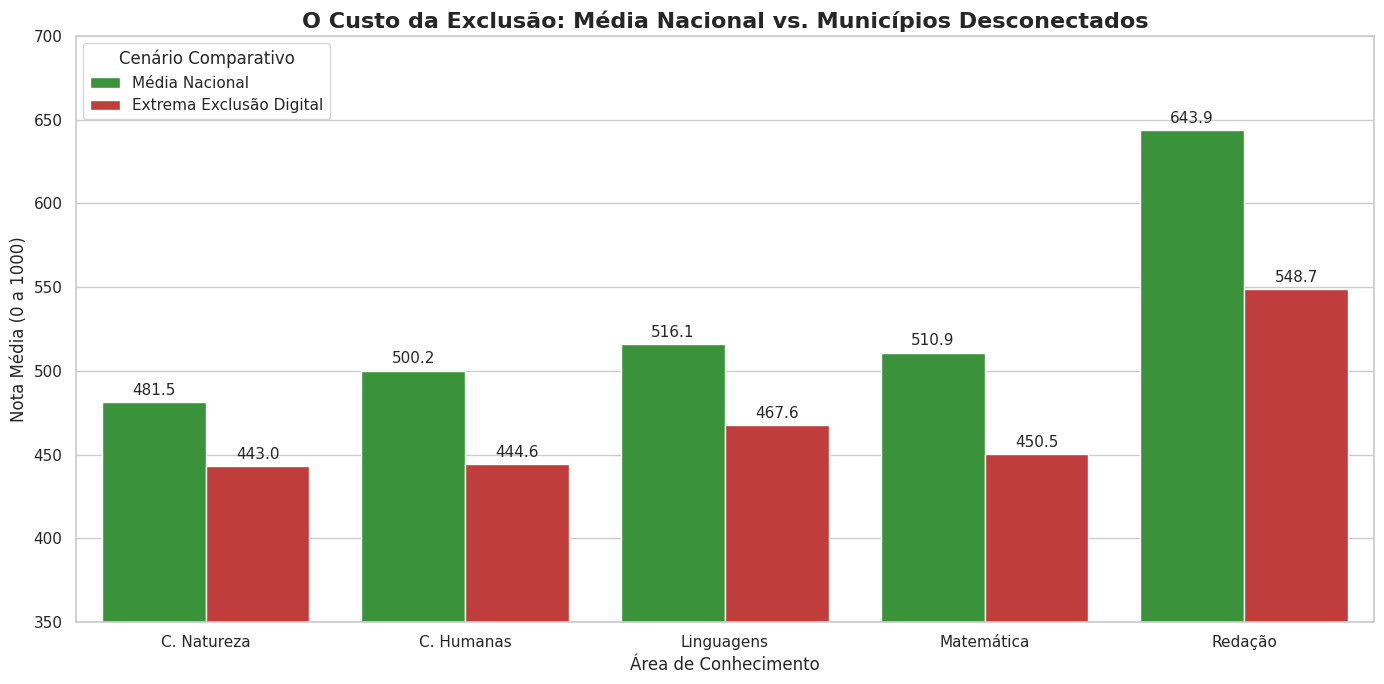

In [10]:
# 1. Utilizando a Camada Silver (Sem filtros de ruído para preservar Outliers)
df_analise = df_master_cidades.copy()

# 2. Criando o Índice de Exclusão (Média entre a falta de PC e falta de Internet)
df_analise['INDICE_EXCLUSAO'] = (df_analise['PERC_SEM_INTERNET'] + df_analise['PERC_SEM_PC']) / 2

# 3. Separando os dois "Brasis" (Top 30 extremos)
cidades_excluidas = df_analise.sort_values(by='INDICE_EXCLUSAO', ascending=False).head(30)
cidades_excluidas['PERFIL'] = 'Exclusão Digital (Sem PC/Net)'

cidades_conectadas = df_analise.sort_values(by='INDICE_EXCLUSAO', ascending=True).head(30)
cidades_conectadas['PERFIL'] = 'Elite Digital (Com PC/Net)'

# Unindo os dois grupos
df_extremos = pd.concat([cidades_excluidas, cidades_conectadas])

print(">>> TOP 5 CIDADES COM MAIOR EXCLUSÃO DIGITAL <<<")
display(cidades_excluidas[['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', 'TOTAL_INSCRITOS', 'INDICE_EXCLUSAO', 'MEDIA_GERAL']].head())

# ---------------------------------------------------------
# DATA VIZ 1: O Boxplot da Fenda Digital (Média Geral)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plotando as Médias GERAIS dos dois grupos
ax1 = sns.boxplot(data=df_extremos, x='PERFIL', y='MEDIA_GERAL', palette=['#d62728', '#1f77b4'])
sns.stripplot(data=df_extremos, x='PERFIL', y='MEDIA_GERAL', color='black', alpha=0.5, jitter=True)

plt.title('O Impacto da Fenda Digital na Média Geral por Município', fontsize=14, fontweight='bold')
plt.xlabel('Perfil Tecnológico do Município', fontsize=12)
plt.ylabel('Média Geral (5 Competências)', fontsize=12)
plt.show()

# ---------------------------------------------------------
# DATA VIZ 2: O Abismo Multidisciplinar (Barplot 5 Competências)
# ---------------------------------------------------------
notas_cols = ['MEDIA_CN', 'MEDIA_CH', 'MEDIA_LC', 'MEDIA_MT', 'MEDIA_REDACAO']
nomes_amigaveis = ['C. Natureza', 'C. Humanas', 'Linguagens', 'Matemática', 'Redação']

# Calculando a média nacional absoluta
media_nacional = df_analise[notas_cols].mean()

# Calculando a média das 30 cidades mais excluídas
media_excluidas = cidades_excluidas[notas_cols].mean()

# Preparando os dados
df_comparativo = pd.DataFrame({
    'Competência': nomes_amigaveis,
    'Média Nacional': media_nacional.values,
    'Extrema Exclusão Digital': media_excluidas.values
})

# "Derretendo" o dataframe para o formato do Seaborn
df_melted = df_comparativo.melt(id_vars='Competência', var_name='Cenário', value_name='Nota Média')

plt.figure(figsize=(14, 7))
ax2 = sns.barplot(data=df_melted, x='Competência', y='Nota Média', hue='Cenário', palette=['#2ca02c', '#d62728'])

plt.title('O Custo da Exclusão: Média Nacional vs. Municípios Desconectados', fontsize=16, fontweight='bold')
plt.ylabel('Nota Média (0 a 1000)', fontsize=12)
plt.xlabel('Área de Conhecimento', fontsize=12)
plt.ylim(350, 700) # Ajuste de eixo para destacar o Gap

# Adicionando os valores nas barras
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', padding=3, fontsize=11)

plt.legend(title='Cenário Comparativo', fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
# Definindo o caminho de saída no seu Google Drive (mesma pasta do projeto)
caminho_saida = '/content/drive/MyDrive/Projeto_ENEM/Base_Consolidada_ML.csv'

# Exportando o DataFrame sem o índice numérico para manter a estrutura limpa
df_master_cidades.to_csv(caminho_saida, sep=';', encoding='latin1', index=False)

print(f"Base salva com sucesso em: {caminho_saida}")
print(f"Dataset final conta com {df_master_cidades.shape[0]} cidades e {df_master_cidades.shape[1]} atributos prontos para modelagem preditiva.")

Base salva com sucesso em: /content/drive/MyDrive/Projeto_ENEM/Base_Consolidada_ML.csv
Dataset final conta com 1753 cidades e 15 atributos prontos para modelagem preditiva.
